# 02 - Entrainement du CNN Baseline
Classification binaire : NORMAL vs PNEUMONIA

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from tqdm import tqdm

In [8]:
# Configuration
DATA_DIR = Path('../data/chest_xray')
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 15
LEARNING_RATE = 1e-3

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cpu


## 1. Chargement des donnees

In [9]:
# Transforms
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Datasets
train_dataset = datasets.ImageFolder(DATA_DIR / 'train', transform=train_transform)
val_dataset = datasets.ImageFolder(DATA_DIR / 'val', transform=test_transform)
test_dataset = datasets.ImageFolder(DATA_DIR / 'test', transform=test_transform)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train: {len(train_dataset)} images")
print(f"Val: {len(val_dataset)} images")
print(f"Test: {len(test_dataset)} images")

Train: 5216 images
Val: 16 images
Test: 624 images


## 2. Definition du CNN Baseline

In [10]:
class CNNBaseline(nn.Module):
    """
    CNN Baseline pour classification binaire
    Architecture:
        Conv(32) + ReLU + MaxPool
        Conv(64) + ReLU + MaxPool
        Conv(128) + ReLU + MaxPool
        Flatten + Dense(128) + Dropout + Dense(1) + Sigmoid
    """
    def __init__(self):
        super(CNNBaseline, self).__init__()
        
        # Couches convolutives
        self.conv_layers = nn.Sequential(
            # Bloc 1: Conv(32)
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 224 -> 112
            
            # Bloc 2: Conv(64)
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 112 -> 56
            
            # Bloc 3: Conv(128)
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 56 -> 28
        )
        
        # Couches fully connected
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

In [11]:
# Initialiser le modele
model = CNNBaseline().to(device)

# Afficher l'architecture
print(model)

# Compter les parametres
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nParametres totaux: {total_params:,}")
print(f"Parametres entrainables: {trainable_params:,}")

CNNBaseline(
  (conv_layers): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=1, bias=True)
    (5): Sigmoid()
  )
)

Parametres totaux: 12,938,561
Parametres entrainables: 12,938,561


## 3. Configuration de l'entrainement

In [12]:
# Calculer les poids des classes pour gerer le desequilibre
train_counts = {'NORMAL': 1341, 'PNEUMONIA': 3875}
total = sum(train_counts.values())
weight_pos = total / (2 * train_counts['PNEUMONIA'])  # poids pour classe positive (PNEUMONIA)

# Loss function avec poids
criterion = nn.BCELoss()

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Scheduler pour reduire le learning rate
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

print(f"Loss: BCELoss")
print(f"Optimizer: Adam (lr={LEARNING_RATE})")
print(f"Scheduler: ReduceLROnPlateau")

Loss: BCELoss
Optimizer: Adam (lr=0.001)
Scheduler: ReduceLROnPlateau


## 4. Fonctions d'entrainement et validation

In [13]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in tqdm(loader, desc="Training", leave=False):
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)
        
        # Forward
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward
        loss.backward()
        optimizer.step()
        
        # Stats
        running_loss += loss.item() * images.size(0)
        predicted = (outputs > 0.5).float()
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            predicted = (outputs > 0.5).float()
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

## 5. Entrainement

In [14]:
# Historique
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

best_val_acc = 0.0
best_model_path = Path('../outputs/checkpoints/best_model.pt')
best_model_path.parent.mkdir(parents=True, exist_ok=True)

print(f"Entrainement sur {EPOCHS} epochs...")
print("=" * 60)

for epoch in range(EPOCHS):
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    
    # Validate
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    
    # Scheduler step
    scheduler.step(val_loss)
    
    # Sauvegarder historique
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    # Sauvegarder le meilleur modele
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"Epoch {epoch+1:2d}/{EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | BEST")
    else:
        print(f"Epoch {epoch+1:2d}/{EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

print("=" * 60)
print(f"Meilleure Val Accuracy: {best_val_acc:.4f}")
print(f"Modele sauvegarde: {best_model_path}")

Entrainement sur 15 epochs...


Epoch  1/15 | Train Loss: 0.3544 | Train Acc: 0.8637 | Val Loss: 0.5971 | Val Acc: 0.7500 | BEST


Epoch  2/15 | Train Loss: 0.1783 | Train Acc: 0.9325 | Val Loss: 0.7484 | Val Acc: 0.6875


Epoch  3/15 | Train Loss: 0.1351 | Train Acc: 0.9502 | Val Loss: 0.4240 | Val Acc: 0.6250


Epoch  4/15 | Train Loss: 0.1221 | Train Acc: 0.9590 | Val Loss: 0.5333 | Val Acc: 0.5625


...

Epoch 11/15 | Train Loss: 0.0837 | Train Acc: 0.9724 | Val Loss: 0.8101 | Val Acc: 0.6250


Epoch 12/15 | Train Loss: 0.0744 | Train Acc: 0.9737 | Val Loss: 0.6322 | Val Acc: 0.6250


Epoch 13/15 | Train Loss: 0.0714 | Train Acc: 0.9762 | Val Loss: 0.4790 | Val Acc: 0.6875


Epoch 14/15 | Train Loss: 0.0700 | Train Acc: 0.9755 | Val Loss: 0.4917 | Val Acc: 0.6875


Epoch 15/15 | Train Loss: 0.0675 | Train Acc: 0.9768 | Val Loss: 0.5408 | Val Acc: 0.6875
Meilleure Val Accuracy: 0.7500
Modele sauvegarde: ..\outputs\checkpoints\best_model.pt


## 6. Visualisation des courbes

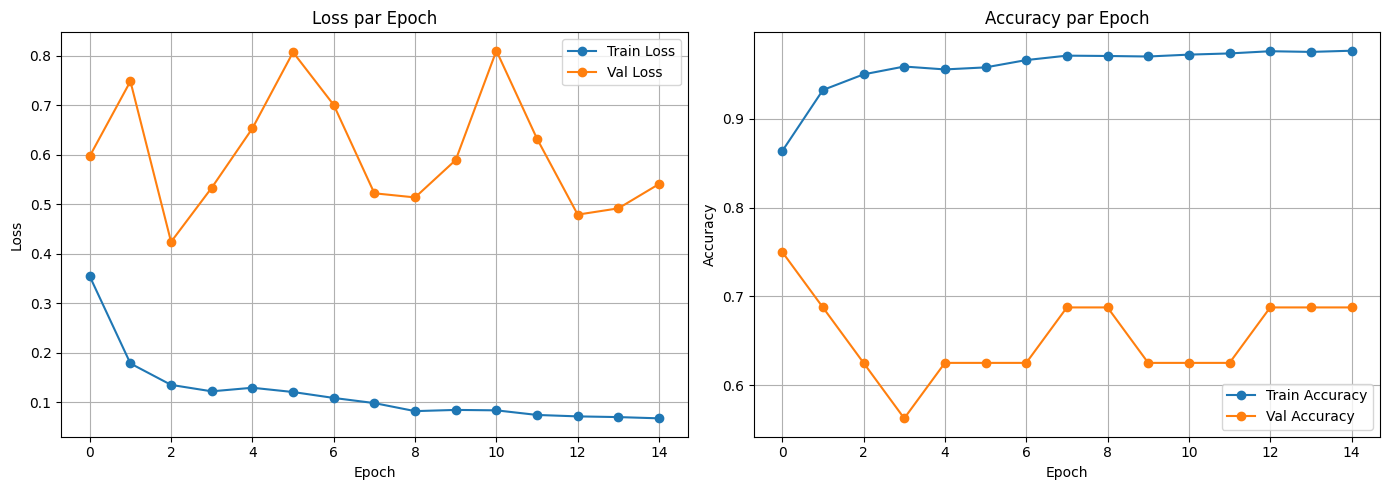

Figure sauvegardee: outputs/figures/training_curves.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(history['val_loss'], label='Val Loss', marker='o')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss par Epoch')
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(history['train_acc'], label='Train Accuracy', marker='o')
axes[1].plot(history['val_acc'], label='Val Accuracy', marker='o')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy par Epoch')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('../outputs/figures/training_curves.png', dpi=150)
plt.show()

print("Figure sauvegardee: outputs/figures/training_curves.png")

## 7. Evaluation sur le Test Set

In [16]:
# Charger le meilleur modele
model.load_state_dict(torch.load(best_model_path))

# Evaluer sur test
test_loss, test_acc = validate(model, test_loader, criterion, device)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Test Loss: 0.5865
Test Accuracy: 0.7628


## Resume

- **CNN Baseline** entraine sur le dataset Chest X-Ray
- **Courbes** de loss et accuracy sauvegardees
- **Meilleur modele** sauvegarde dans `outputs/checkpoints/`
- **Prochain notebook**: Evaluation detaillee (matrice confusion, metriques, Grad-CAM)